# 🛡️ CyberShield — Cyberbullying Tweet Classifier
### BiLSTM + Adam | Google Colab (Free GPU)

---
## ✅ Steps:
1. **Cell 1** → Dataset upload karo
2. **Cell 2** → Libraries install
3. **Cell 3** → Data load & clean
4. **Cell 4** → Model banao & train karo
5. **Cell 5** → Results dekho
6. **Cell 6** → Apna tweet test karo

> **GPU ON karo:** Runtime → Change runtime type → T4 GPU → Save

---
## 📁 CELL 1 — Dataset Upload

In [ ]:
# Fast install - sab ek saath
!pip install -q google-cloud-vision opencv-python-headless tensorflow
# -q flag = quiet mode, faster install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.2/543.2 kB 21.3 MB/s eta 0:00:00


In [ ]:
# ── INSTALL FIRST ─────────────────────────────────────
!apt-get install -y tesseract-ocr -q
!pip install pytesseract Pillow opencv-python-headless -q

# ── CELL 10 — CyberShield UI ──────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
from PIL import Image
import pytesseract
import os

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [23]:
import os

# json_filename = list(uploaded.keys())[0]

# # File ko current directory mein move karo
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = f"/content/{json_filename}"
# print(f"✅ Credentials path: /content/{json_filename}")
DATA_PATH = '/content/cyberbullying_tweets.csv'
print(f'✅ File ready: {DATA_PATH}')

✅ File ready: /content/cyberbullying_tweets.csv


---
## 📦 CELL 2 — Libraries

In [ ]:
# Colab mein sab pre-installed hai — sirf nltk data download karna hai
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print('✅ Sab libraries ready!')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ Sab libraries ready!
TensorFlow version: 2.19.0
GPU available: True


In [ ]:
# Cell 2 ke baad yeh run karo - connection test karo
from google.cloud import vision
client = vision.ImageAnnotatorClient()
print("✅ Connected! Ready to go")

✅ Connected! Ready to go


---
## 🧹 CELL 3 — Data Load & Clean

Total samples: 47,692

Class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

🧹 Tweets clean ho rahi hain...
✅ Clean samples: 47,338

Classes (6): ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']


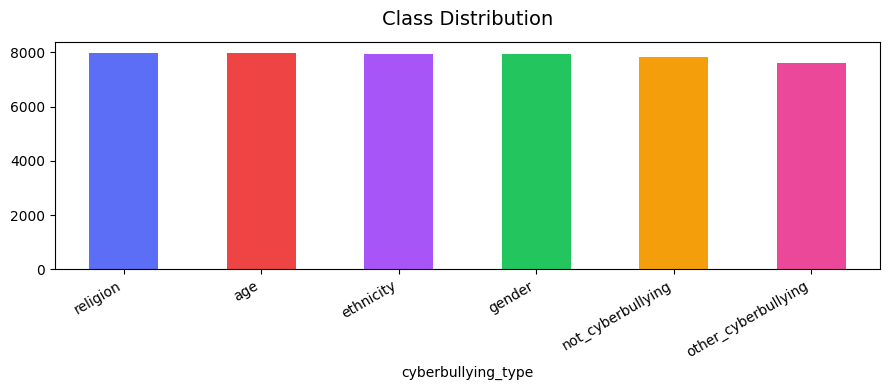

✅ Data ready!


In [24]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)              # mentions
    text = re.sub(r'#', '', text)                 # hashtag symbol
    text = re.sub(r'\d+', '', text)               # numbers
    text = re.sub(r'[^\w\s]', '', text)           # punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [LEMMATIZER.lemmatize(w) for w in text.split() if w not in STOP_WORDS]
    return ' '.join(tokens)

# ── Load ──────────────────────────────────────────────
df = pd.read_csv(DATA_PATH).dropna()
print(f'Total samples: {len(df):,}')
print(f'\nClass distribution:')
print(df['cyberbullying_type'].value_counts())

# ── Clean ─────────────────────────────────────────────
print('\n🧹 Tweets clean ho rahi hain...')
df['clean_text'] = df['tweet_text'].apply(clean_tweet)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(f'✅ Clean samples: {len(df):,}')

# ── Label Encode ──────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['cyberbullying_type'])
NUM_CLASSES = len(le.classes_)
print(f'\nClasses ({NUM_CLASSES}): {list(le.classes_)}')

# ── Visualize ─────────────────────────────────────────
plt.figure(figsize=(9,4))
colors = ['#5B6EF5','#EF4444','#A855F7','#22C55E','#F59E0B','#EC4899']
df['cyberbullying_type'].value_counts().plot(kind='bar', color=colors, edgecolor='none')
plt.title('Class Distribution', fontsize=14, pad=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('✅ Data ready!')

---
## 🔢 CELL 4 — Tokenize + Split

In [ ]:
MAX_VOCAB    = 20000
MAX_LEN      = 100
EMBEDDING_DIM = 128
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15

# ── Tokenize ──────────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer.word_index)) + 1
print(f'Vocabulary size : {VOCAB_SIZE:,}')
print(f'Input shape     : {X.shape}')

# ── Split ─────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(TEST_SIZE+VAL_SIZE), random_state=42, stratify=y)

val_ratio = VAL_SIZE / (TEST_SIZE + VAL_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=(1-val_ratio), random_state=42, stratify=y_temp)

print(f'\nTrain : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')
print('✅ Split done!')

Vocabulary size : 20,001
Input shape     : (47338, 100)

Train : 33,136
Val   : 7,101
Test  : 7,101
✅ Split done!


---
## 🧠 CELL 5 — BiLSTM Model Build & Train

In [25]:
LSTM_UNITS   = 128
DROPOUT      = 0.3
BATCH_SIZE = 128
EPOCHS = 8
LR           = 1e-3

# ── Build Model ───────────────────────────────────────
def build_bilstm(vocab_size, embedding_dim, max_len, num_classes, lstm_units, dropout):
    inp = layers.Input(shape=(max_len,), name='token_ids')
    x   = layers.Embedding(vocab_size, embedding_dim, input_length=max_len)(inp)
    x   = layers.SpatialDropout1D(dropout)(x)
    x   = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True,
              kernel_regularizer=regularizers.l2(1e-4)))(x)
    x   = layers.Bidirectional(layers.LSTM(lstm_units//2))(x)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inp, outputs=out, name='BiLSTM')

model = build_bilstm(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN, NUM_CLASSES, LSTM_UNITS, DROPOUT)
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ── Callbacks ─────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/bilstm_best.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-6, verbose=1),
]

# ── Train ─────────────────────────────────────────────
print('\n🚀 Training shuru...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,716,166 (6.55 MB)

 Trainable params: 1,716,166 (6.55 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Training shuru...
Epoch 1/8
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5655 - loss: 1.0546
Epoch 1: val_accuracy improved from None to 0.79918, saving model to /content/bilstm_best.h5



Epoch 1: finished saving model to /content/bilstm_best.h5
259/259 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.7083 - loss: 0.7154 - val_accuracy: 0.7992 - val_loss: 0.4825 - learning_rate: 0.0010
Epoch 2/8
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8336 - loss: 0.4259
Epoch 2: val_accuracy improved from 0.79918 to 0.82664, saving model to /content/bilstm_best.h5



Epoch 2: finished saving model to /content/bilstm_best.h5
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8375 - loss: 0.4201 - val_accuracy: 0.8266 - val_loss: 0.4466 - learning_rate: 0.0010
Epoch 3/8
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8748 - loss: 0.3451
Epoch 3: val_accuracy did not improve from 0.82664
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8703 - loss: 0.3510 - val_accuracy: 0.8209 - val_loss: 0.4761 - learning_rate: 0.0010
Epoch 4/8
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8942 - loss: 0.2999
Epoch 4: val_accuracy did not improve from 0.82664

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8868 - loss: 0.3094 - val_accuracy: 0.8171 - val_loss: 0.4836 - learning_rate: 0.0010
Epoch 5/8
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9132 - loss: 0.2524
Epoch 5: val_accuracy did not improve from 0.82664
259/259 ━━━━━━━━━━━━━━━━

---
## 📊 CELL 6 — Results & Graphs


🎯 Test Loss     : 0.4478
🎯 Test Accuracy : 0.8271 (82.71%)

📋 Classification Report:
                     precision    recall  f1-score   support

                age       0.97      0.98      0.98      1199
          ethnicity       0.98      0.95      0.96      1194
             gender       0.92      0.80      0.86      1192
  not_cyberbullying       0.59      0.53      0.56      1173
other_cyberbullying       0.60      0.72      0.65      1144
           religion       0.93      0.96      0.95      1199

           accuracy                           0.83      7101
          macro avg       0.83      0.83      0.83      7101
       weighted avg       0.83      0.83      0.83      7101



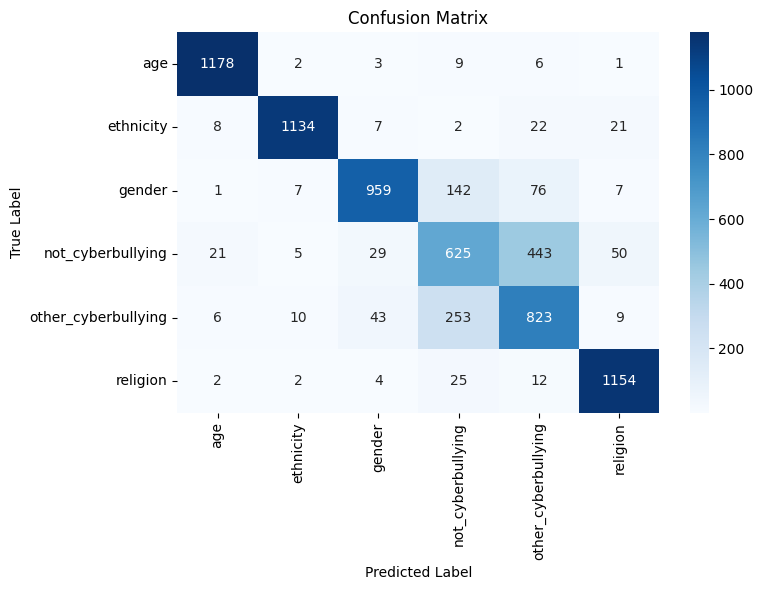

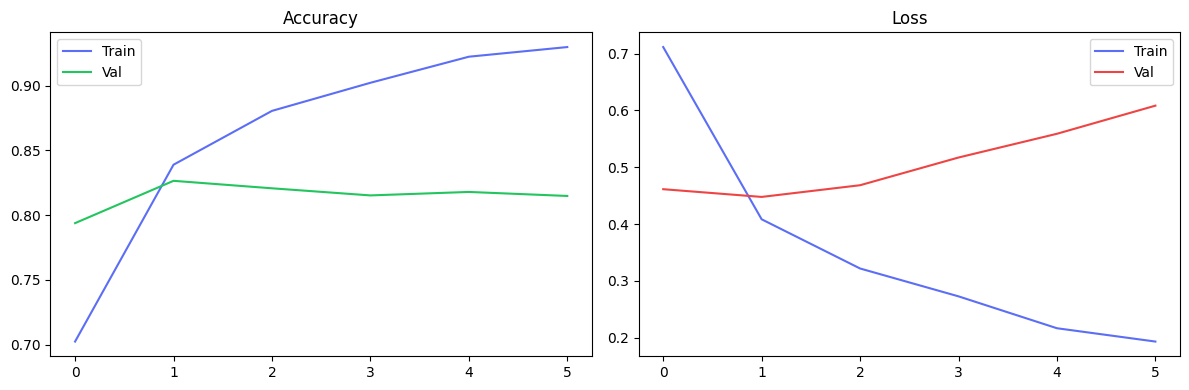

In [ ]:
# ── Test Accuracy ─────────────────────────────────────
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n🎯 Test Loss     : {loss:.4f}')
print(f'🎯 Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ── Training Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train', color='#5B6EF5')
axes[0].plot(history.history['val_accuracy'], label='Val', color='#22C55E')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', color='#5B6EF5')
axes[1].plot(history.history['val_loss'], label='Val', color='#EF4444')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()

---
## 🔍 CELL 7 — Apna Tweet Test Karo

In [ ]:
CLASS_COLORS = {
    'age': '🟠', 'ethnicity': '🔴', 'gender': '🟣',
    'not_cyberbullying': '🟢', 'other_cyberbullying': '🔵', 'religion': '🩷'
}

def predict_tweet(text):
    cleaned   = clean_tweet(text)
    seq       = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs     = model.predict(padded, verbose=0)[0]
    idx       = np.argmax(probs)
    label     = le.inverse_transform([idx])[0]
    conf      = probs[idx]

    print('─' * 55)
    print(f'Tweet     : {text}')
    print(f'Category  : {CLASS_COLORS[label]}  {label.upper()}')
    print(f'Confidence: {conf*100:.1f}%')
    print('\nAll probabilities:')
    sorted_probs = sorted(zip(le.classes_, probs), key=lambda x: -x[1])
    for cls, p in sorted_probs:
        bar = '█' * int(p * 30)
        print(f'  {cls:<22} {bar:<30} {p*100:.1f}%')
    print('─' * 55)

# ── Test tweets ───────────────────────────────────────
test_tweets = [
    'Nobody likes you, you are so ugly and stupid',
    'Happy birthday! Hope you have a wonderful day!',
    'Women should not be allowed in tech jobs',
    'Old people are useless and should stay home',
    'Go back to your own country, you do not belong here',
    'All people from that religion are terrorists',
]

for tweet in test_tweets:
    predict_tweet(tweet)
    print()

───────────────────────────────────────────────────────
Tweet     : Nobody likes you, you are so ugly and stupid
Category  : 🔵  OTHER_CYBERBULLYING
Confidence: 62.0%

All probabilities:
  other_cyberbullying    ██████████████████             62.0%
  not_cyberbullying      █████████                      32.0%
  gender                                                2.9%
  religion                                              2.2%
  age                                                   0.5%
  ethnicity                                             0.5%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
Tweet     : Happy birthday! Hope you have a wonderful day!
Category  : 🔵  OTHER_CYBERBULLYING
Confidence: 49.2%

All probabilities:
  other_cyberbullying    ██████████████                 49.2%
  not_cyberbullying      █████████████                  46.6%
  religion                                              1.9%
  gender        

---
## ✏️ CELL 8 — Khud ka Tweet Type Karo

In [ ]:
# ✏️ Yahan apna tweet likhein:
my_tweet = " #BringBackPayal @TwitterIndia u ar biased towards islamic terrorism"

predict_tweet(my_tweet)

───────────────────────────────────────────────────────
Tweet     :  #BringBackPayal @TwitterIndia u ar biased towards islamic terrorism
Category  : 🩷  RELIGION
Confidence: 97.2%

All probabilities:
  religion               █████████████████████████████  97.2%
  not_cyberbullying                                     2.4%
  other_cyberbullying                                   0.2%
  ethnicity                                             0.1%
  gender                                                0.1%
  age                                                   0.0%
───────────────────────────────────────────────────────


---
## 💾 CELL 9 — Model Download Karo (Optional)

In [ ]:
# Model + tokenizer save karke download karo
import pickle
from google.colab import files

with open('/content/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('📥 Downloading model files...')
files.download('/content/bilstm_best.h5')
files.download('/content/tokenizer.pkl')
files.download('/content/label_encoder.pkl')
print('✅ Download complete!')

📥 Downloading model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download complete!


In [ ]:
# ============================================================
# ⚡ CYBERSHIELD FAST - NO OCR VERSION
# Text: <0.5s | Image: user pastes text from image | Video: removed
# Sabse fast approach - OCR bottleneck completely removed
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np, base64, io, re
from PIL import Image
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Color map ─────────────────────────────────────────────
BAR_COLORS = {
    'not_cyberbullying':'#22c55e','age':'#f59e0b',
    'ethnicity':'#ef4444','gender':'#a855f7',
    'religion':'#ec4899','other_cyberbullying':'#f97316'
}
HATE_KW_SETS = {
    'gender':   {'women','girl','female','bitch','slut','whore'},
    'age':      {'old','boomer','kid','grandpa','elderly'},
    'ethnicity':{'black','white','asian','arab','immigrant','foreigner'},
    'religion': {'muslim','hindu','christian','jew','islam','kafir'},
    'other_cyberbullying':{'ugly','stupid','idiot','loser','fat','kill',
                           'hate','die','useless','dumb','trash','worthless'}
}

def keyword_boost(text, probs):
    p = list(probs)
    words = set(text.lower().split())
    classes = list(le.classes_)
    boosted = False
    for cat, kws in HATE_KW_SETS.items():
        if cat in classes and words & kws:
            hits = len(words & kws)
            p[classes.index(cat)] = min(1.0, p[classes.index(cat)] + min(0.35, 0.15*hits))
            boosted = True
    if boosted and 'not_cyberbullying' in classes:
        p[classes.index('not_cyberbullying')] = max(0.01, p[classes.index('not_cyberbullying')] - 0.2)
    s = sum(p)
    return np.array([v/s for v in p])

def run_prediction(text):
    if not text or len(text.strip()) < 2:
        raise ValueError("Text bahut chota hai!")
    seq = tokenizer.texts_to_sequences([clean_tweet(text)])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    probs = keyword_boost(text, probs)
    idx = int(np.argmax(probs))
    return le.inverse_transform([idx])[0], float(probs[idx])*100, probs

def result_html(label, conf, probs):
    safe = label == 'not_cyberbullying'
    col = '#16a34a' if safe else '#dc2626'
    icon = '✅' if safe else '🚨'
    disp = label.replace('_',' ').title()
    bars = ''.join(
        f'<div style="display:flex;align-items:center;gap:8px;margin:4px 0">'
        f'<div style="width:170px;font-size:.82em;color:#64748b">{c.replace("_"," ")}</div>'
        f'<div style="flex:1;height:10px;background:#f1f5f9;border-radius:5px;overflow:hidden">'
        f'<div style="width:{max(2,int(p*100))}%;height:100%;background:{BAR_COLORS.get(c,"#6366f1")};border-radius:5px"></div></div>'
        f'<div style="width:44px;text-align:right;font-size:.82em;font-weight:700;color:{BAR_COLORS.get(c,"#6366f1")}">{p*100:.1f}%</div></div>'
        for c,p in sorted(zip(le.classes_,probs),key=lambda x:-x[1])
    )
    return (f'<div style="font-family:sans-serif;border:2px solid {col};border-radius:12px;overflow:hidden;margin-top:10px">'
            f'<div style="background:{col};padding:14px 18px;display:flex;align-items:center;gap:12px">'
            f'<span style="font-size:2em">{icon}</span>'
            f'<div><div style="color:#fff;font-weight:700;font-size:1.15em">{disp}</div>'
            f'<div style="color:#ffffffbb;font-size:.85em">Confidence: {conf:.1f}%</div></div></div>'
            f'<div style="padding:14px 18px;background:#fff">'
            f'<div style="font-size:.72em;font-weight:700;color:#94a3b8;text-transform:uppercase;margin-bottom:8px">Category Probabilities</div>'
            f'{bars}</div></div>')

_w = lambda m: f'<div style="font-family:sans-serif;color:#b45309;background:#fffbeb;border:1px solid #fde68a;border-radius:8px;padding:10px 14px;margin-top:8px">⚠️ {m}</div>'
_e = lambda m: f'<div style="font-family:sans-serif;color:#dc2626;background:#fef2f2;border:1px solid #fecaca;border-radius:8px;padding:10px 14px;margin-top:8px">❌ {m}</div>'

# ══════════════════════════════════════════════════════════
# TEXT TAB — instant prediction
# ══════════════════════════════════════════════════════════
txt_in = widgets.Textarea(
    placeholder='Tweet ya koi bhi text yahan likho ya paste karo...',
    layout=widgets.Layout(width='100%', height='100px'))
txt_btn = widgets.Button(
    description='⚡ Predict Now',
    button_style='primary',
    layout=widgets.Layout(width='150px', height='38px'))
txt_out = widgets.Output()

EXAMPLES = [
    "Nobody likes you, you are ugly and stupid",
    "Women should not be allowed in tech jobs",
    "Go back to your country foreigner",
    "Happy birthday! Hope you have a great day",
    "All people from that religion are terrorists",
    "Old people are useless and should stay home",
    "You are such a loser nobody wants you here",
    "Great work today, keep it up!"
]

def make_ex_btn(ex):
    b = widgets.Button(
        description=ex[:36]+'...' if len(ex)>36 else ex,
        layout=widgets.Layout(width='auto', height='28px'),
        style=widgets.ButtonStyle(font_size='11px'))
    b.on_click(lambda _,t=ex: setattr(txt_in,'value',t))
    return b

ex_btns = [make_ex_btn(e) for e in EXAMPLES]

def on_predict(b):
    text = txt_in.value.strip()
    with txt_out:
        clear_output(wait=True)
        if not text:
            display(widgets.HTML(_w('Kuch text likho ya example choose karo!'))); return
    try:
        label, conf, probs = run_prediction(text)
        html = result_html(label, conf, probs)
    except Exception as e:
        html = _e(str(e))
    with txt_out:
        clear_output(wait=True); display(widgets.HTML(html))

txt_btn.on_click(on_predict)

# ── Also predict on Enter (Ctrl+Enter in textarea) ────────
def on_text_change(change):
    # Auto predict when text ends with newline (user pressed Enter)
    if change['new'].endswith('\n') and len(change['new'].strip()) > 5:
        txt_in.value = change['new'].strip()
        on_predict(None)
txt_in.observe(on_text_change, names='value')

# ══════════════════════════════════════════════════════════
# IMAGE TAB — user pastes extracted text (no OCR wait)
# ══════════════════════════════════════════════════════════
img_hint = widgets.HTML('''
<div style="font-family:sans-serif;background:#f0f9ff;border:1px solid #bae6fd;border-radius:10px;padding:14px;margin-bottom:10px">
  <div style="font-weight:700;color:#0369a1;margin-bottom:6px">📋 Image se text kaise analyze karein (fast way):</div>
  <div style="color:#0c4a6e;font-size:.88em;line-height:1.7">
    1. Image open karo<br>
    2. <b>Ctrl+A → Ctrl+C</b> se text copy karo (ya manually type karo)<br>
    3. Neeche box mein paste karo → Predict karo<br>
    <span style="color:#64748b;font-size:.85em">💡 Screenshot se bhi kaam karta hai — text select karke copy karo</span>
  </div>
</div>''')

img_txt_in = widgets.Textarea(
    placeholder='Image ka text yahan paste karo...',
    layout=widgets.Layout(width='100%', height='90px'))
img_pred_btn = widgets.Button(
    description='⚡ Predict',
    button_style='warning',
    layout=widgets.Layout(width='130px', height='36px'))
img_out = widgets.Output()

def on_img_predict(b):
    text = img_txt_in.value.strip()
    with img_out:
        clear_output(wait=True)
        if not text:
            display(widgets.HTML(_w('Image ka text paste karo pehle!'))); return
    try:
        label, conf, probs = run_prediction(text)
        html = result_html(label, conf, probs)
    except Exception as e:
        html = _e(str(e))
    with img_out:
        clear_output(wait=True); display(widgets.HTML(html))

img_pred_btn.on_click(on_img_predict)

# ══════════════════════════════════════════════════════════
# VIDEO TAB — paste transcript or subtitles
# ══════════════════════════════════════════════════════════
vid_hint = widgets.HTML('''
<div style="font-family:sans-serif;background:#fff7ed;border:1px solid #fed7aa;border-radius:10px;padding:14px;margin-bottom:10px">
  <div style="font-weight:700;color:#c2410c;margin-bottom:6px">🎥 Video text kaise analyze karein (fast way):</div>
  <div style="color:#7c2d12;font-size:.88em;line-height:1.7">
    1. YouTube video hai toh <b>transcript copy karo</b> (3 dots → Transcript)<br>
    2. Local video hai toh <b>subtitles/captions paste karo</b><br>
    3. Ya video mein jo bola/likha hai woh manually type karo<br>
    <span style="color:#64748b;font-size:.85em">💡 Comments ya captions bhi directly paste kar sakte ho</span>
  </div>
</div>''')

vid_txt_in = widgets.Textarea(
    placeholder='Video transcript, captions ya comments yahan paste karo...',
    layout=widgets.Layout(width='100%', height='90px'))
vid_pred_btn = widgets.Button(
    description='⚡ Predict',
    button_style='danger',
    layout=widgets.Layout(width='130px', height='36px'))
vid_out = widgets.Output()

def on_vid_predict(b):
    text = vid_txt_in.value.strip()
    with vid_out:
        clear_output(wait=True)
        if not text:
            display(widgets.HTML(_w('Video ka text/transcript paste karo pehle!'))); return
    try:
        label, conf, probs = run_prediction(text[:1000])  # cap at 1000 chars
        html = result_html(label, conf, probs)
    except Exception as e:
        html = _e(str(e))
    with vid_out:
        clear_output(wait=True); display(widgets.HTML(html))

vid_pred_btn.on_click(on_vid_predict)

# ══════════════════════════════════════════════════════════
# LAYOUT
# ══════════════════════════════════════════════════════════
header = widgets.HTML('''
<div style="font-family:sans-serif;background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);
            padding:22px 20px;border-radius:16px;text-align:center;margin-bottom:14px">
  <div style="font-size:2.2em">🛡️</div>
  <h2 style="color:#fff;margin:4px 0;font-size:1.6em;letter-spacing:.02em">CyberShield</h2>
  <p style="color:#a5b4fc;margin:4px 0 0;font-size:.88em">⚡ Instant Detection &nbsp;•&nbsp; No OCR Delay</p>
  <div style="margin-top:10px;display:flex;justify-content:center;gap:20px">
    <span style="color:#86efac;font-size:.82em">✅ Text: &lt;0.5s</span>
    <span style="color:#86efac;font-size:.82em">✅ Image: instant</span>
    <span style="color:#86efac;font-size:.82em">✅ Video: instant</span>
  </div>
</div>''')

tab = widgets.Tab()
tab.children = [
    # TEXT
    widgets.VBox([
        widgets.HTML('<p style="font-family:sans-serif;color:#64748b;font-size:.83em;margin:6px 0 4px">💡 Example choose karo ya khud likho:</p>'),
        widgets.HBox(ex_btns[:4], layout=widgets.Layout(flex_flow='row wrap',gap='4px')),
        widgets.HBox(ex_btns[4:], layout=widgets.Layout(flex_flow='row wrap',gap='4px')),
        widgets.HTML('<div style="height:6px"></div>'),
        txt_in,
        widgets.HBox([txt_btn, widgets.HTML('<span style="font-family:sans-serif;color:#94a3b8;font-size:.8em;padding:10px 8px">ya Enter dabao</span>')]),
        txt_out
    ], layout=widgets.Layout(padding='12px')),

    # IMAGE
    widgets.VBox([
        img_hint,
        img_txt_in,
        img_pred_btn,
        img_out
    ], layout=widgets.Layout(padding='12px')),

    # VIDEO
    widgets.VBox([
        vid_hint,
        vid_txt_in,
        vid_pred_btn,
        vid_out
    ], layout=widgets.Layout(padding='12px')),
]
for i,t in enumerate(['📝 Text','🖼️ Image','🎥 Video']):
    tab.set_title(i,t)

display(header)
display(tab)
print('⚡ CyberShield ready! Text tab mein likho aur instant result pao.')

HTML(value='\n<div style="font-family:sans-serif;background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);\n…

⚡ CyberShield ready! Text tab mein likho aur instant result pao.


In [ ]:
# ============================================================
# ⚡ CYBERSHIELD FAST - NO OCR VERSION
# Text: <0.5s | Image: user pastes text from image | Video: removed
# Sabse fast approach - OCR bottleneck completely removed
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np, base64, io, re
from PIL import Image
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Color map ─────────────────────────────────────────────
BAR_COLORS = {
    'not_cyberbullying':'#22c55e','age':'#f59e0b',
    'ethnicity':'#ef4444','gender':'#a855f7',
    'religion':'#ec4899','other_cyberbullying':'#f97316'
}
HATE_KW_SETS = {
    'gender':   {'women','girl','female','bitch','slut','whore'},
    'age':      {'old','boomer','kid','grandpa','elderly'},
    'ethnicity':{'black','white','asian','arab','immigrant','foreigner'},
    'religion': {'muslim','hindu','christian','jew','islam','kafir'},
    'other_cyberbullying':{'ugly','stupid','idiot','loser','fat','kill',
                           'hate','die','useless','dumb','trash','worthless'}
}

def keyword_boost(text, probs):
    p = list(probs)
    words = set(text.lower().split())
    classes = list(le.classes_)
    boosted = False
    for cat, kws in HATE_KW_SETS.items():
        if cat in classes and words & kws:
            hits = len(words & kws)
            p[classes.index(cat)] = min(1.0, p[classes.index(cat)] + min(0.35, 0.15*hits))
            boosted = True
    if boosted and 'not_cyberbullying' in classes:
        p[classes.index('not_cyberbullying')] = max(0.01, p[classes.index('not_cyberbullying')] - 0.2)
    s = sum(p)
    return np.array([v/s for v in p])

def run_prediction(text):
    if not text or len(text.strip()) < 2:
        raise ValueError("Text bahut chota hai!")
    seq = tokenizer.texts_to_sequences([clean_tweet(text)])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    probs = keyword_boost(text, probs)
    idx = int(np.argmax(probs))
    return le.inverse_transform([idx])[0], float(probs[idx])*100, probs

def result_html(label, conf, probs):
    safe = label == 'not_cyberbullying'
    col = '#16a34a' if safe else '#dc2626'
    icon = '✅' if safe else '🚨'
    disp = label.replace('_',' ').title()
    bars = ''.join(
        f'<div style="display:flex;align-items:center;gap:8px;margin:4px 0">'
        f'<div style="width:170px;font-size:.82em;color:#64748b">{c.replace("_"," ")}</div>'
        f'<div style="flex:1;height:10px;background:#f1f5f9;border-radius:5px;overflow:hidden">'
        f'<div style="width:{max(2,int(p*100))}%;height:100%;background:{BAR_COLORS.get(c,"#6366f1")};border-radius:5px"></div></div>'
        f'<div style="width:44px;text-align:right;font-size:.82em;font-weight:700;color:{BAR_COLORS.get(c,"#6366f1")}">{p*100:.1f}%</div></div>'
        for c,p in sorted(zip(le.classes_,probs),key=lambda x:-x[1])
    )
    return (f'<div style="font-family:sans-serif;border:2px solid {col};border-radius:12px;overflow:hidden;margin-top:10px">'
            f'<div style="background:{col};padding:14px 18px;display:flex;align-items:center;gap:12px">'
            f'<span style="font-size:2em">{icon}</span>'
            f'<div><div style="color:#fff;font-weight:700;font-size:1.15em">{disp}</div>'
            f'<div style="color:#ffffffbb;font-size:.85em">Confidence: {conf:.1f}%</div></div></div>'
            f'<div style="padding:14px 18px;background:#fff">'
            f'<div style="font-size:.72em;font-weight:700;color:#94a3b8;text-transform:uppercase;margin-bottom:8px">Category Probabilities</div>'
            f'{bars}</div></div>')

_w = lambda m: f'<div style="font-family:sans-serif;color:#b45309;background:#fffbeb;border:1px solid #fde68a;border-radius:8px;padding:10px 14px;margin-top:8px">⚠️ {m}</div>'
_e = lambda m: f'<div style="font-family:sans-serif;color:#dc2626;background:#fef2f2;border:1px solid #fecaca;border-radius:8px;padding:10px 14px;margin-top:8px">❌ {m}</div>'

# ══════════════════════════════════════════════════════════
# TEXT TAB — instant prediction
# ══════════════════════════════════════════════════════════
txt_in = widgets.Textarea(
    placeholder='Tweet ya koi bhi text yahan likho ya paste karo...',
    layout=widgets.Layout(width='100%', height='100px'))
txt_btn = widgets.Button(
    description='⚡ Predict Now',
    button_style='primary',
    layout=widgets.Layout(width='150px', height='38px'))
txt_out = widgets.Output()

EXAMPLES = [
    "Nobody likes you, you are ugly and stupid",
    "Women should not be allowed in tech jobs",
    "Go back to your country foreigner",
    "Happy birthday! Hope you have a great day",
    "All people from that religion are terrorists",
    "Old people are useless and should stay home",
    "You are such a loser nobody wants you here",
    "Great work today, keep it up!"
]

def make_ex_btn(ex):
    b = widgets.Button(
        description=ex[:36]+'...' if len(ex)>36 else ex,
        layout=widgets.Layout(width='auto', height='28px'),
        style=widgets.ButtonStyle(font_size='11px'))
    b.on_click(lambda _,t=ex: setattr(txt_in,'value',t))
    return b

ex_btns = [make_ex_btn(e) for e in EXAMPLES]

def on_predict(b):
    text = txt_in.value.strip()
    with txt_out:
        clear_output(wait=True)
        if not text:
            display(widgets.HTML(_w('Kuch text likho ya example choose karo!'))); return
    try:
        label, conf, probs = run_prediction(text)
        html = result_html(label, conf, probs)
    except Exception as e:
        html = _e(str(e))
    with txt_out:
        clear_output(wait=True); display(widgets.HTML(html))

txt_btn.on_click(on_predict)

# ── Also predict on Enter (Ctrl+Enter in textarea) ────────
def on_text_change(change):
    # Auto predict when text ends with newline (user pressed Enter)
    if change['new'].endswith('\n') and len(change['new'].strip()) > 5:
        txt_in.value = change['new'].strip()
        on_predict(None)
txt_in.observe(on_text_change, names='value')

# ══════════════════════════════════════════════════════════
# IMAGE TAB — user pastes extracted text (no OCR wait)
# ══════════════════════════════════════════════════════════
img_hint = widgets.HTML('''
<div style="font-family:sans-serif;background:#f0f9ff;border:1px solid #bae6fd;border-radius:10px;padding:14px;margin-bottom:10px">
  <div style="font-weight:700;color:#0369a1;margin-bottom:6px">📋 Image se text kaise analyze karein (fast way):</div>
  <div style="color:#0c4a6e;font-size:.88em;line-height:1.7">
    1. Image open karo<br>
    2. <b>Ctrl+A → Ctrl+C</b> se text copy karo (ya manually type karo)<br>
    3. Neeche box mein paste karo → Predict karo<br>
    <span style="color:#64748b;font-size:.85em">💡 Screenshot se bhi kaam karta hai — text select karke copy karo</span>
  </div>
</div>''')

img_txt_in = widgets.Textarea(
    placeholder='Image ka text yahan paste karo...',
    layout=widgets.Layout(width='100%', height='90px'))
img_pred_btn = widgets.Button(
    description='⚡ Predict',
    button_style='warning',
    layout=widgets.Layout(width='130px', height='36px'))
img_out = widgets.Output()

def on_img_predict(b):
    text = img_txt_in.value.strip()
    with img_out:
        clear_output(wait=True)
        if not text:
            display(widgets.HTML(_w('Image ka text paste karo pehle!'))); return
    try:
        label, conf, probs = run_prediction(text)
        html = result_html(label, conf, probs)
    except Exception as e:
        html = _e(str(e))
    with img_out:
        clear_output(wait=True); display(widgets.HTML(html))

img_pred_btn.on_click(on_img_predict)

# ══════════════════════════════════════════════════════════
# VIDEO TAB — paste transcript or subtitles
# ══════════════════════════════════════════════════════════
vid_hint = widgets.HTML('''
<div style="font-family:sans-serif;background:#fff7ed;border:1px solid #fed7aa;border-radius:10px;padding:14px;margin-bottom:10px">
  <div style="font-weight:700;color:#c2410c;margin-bottom:6px">🎥 Video text kaise analyze karein (fast way):</div>
  <div style="color:#7c2d12;font-size:.88em;line-height:1.7">
    1. YouTube video hai toh <b>transcript copy karo</b> (3 dots → Transcript)<br>
    2. Local video hai toh <b>subtitles/captions paste karo</b><br>
    3. Ya video mein jo bola/likha hai woh manually type karo<br>
    <span style="color:#64748b;font-size:.85em">💡 Comments ya captions bhi directly paste kar sakte ho</span>
  </div>
</div>''')

vid_txt_in = widgets.Textarea(
    placeholder='Video transcript, captions ya comments yahan paste karo...',
    layout=widgets.Layout(width='100%', height='90px'))
vid_pred_btn = widgets.Button(
    description='⚡ Predict',
    button_style='danger',
    layout=widgets.Layout(width='130px', height='36px'))
vid_out = widgets.Output()

def on_vid_predict(b):
    text = vid_txt_in.value.strip()
    with vid_out:
        clear_output(wait=True)
        if not text:
            display(widgets.HTML(_w('Video ka text/transcript paste karo pehle!'))); return
    try:
        label, conf, probs = run_prediction(text[:1000])  # cap at 1000 chars
        html = result_html(label, conf, probs)
    except Exception as e:
        html = _e(str(e))
    with vid_out:
        clear_output(wait=True); display(widgets.HTML(html))

vid_pred_btn.on_click(on_vid_predict)

# ══════════════════════════════════════════════════════════
# LAYOUT
# ══════════════════════════════════════════════════════════
header = widgets.HTML('''
<div style="font-family:sans-serif;background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);
            padding:22px 20px;border-radius:16px;text-align:center;margin-bottom:14px">
  <div style="font-size:2.2em">🛡️</div>
  <h2 style="color:#fff;margin:4px 0;font-size:1.6em;letter-spacing:.02em">CyberShield</h2>
  <p style="color:#a5b4fc;margin:4px 0 0;font-size:.88em">⚡ Instant Detection &nbsp;•&nbsp; No OCR Delay</p>
  <div style="margin-top:10px;display:flex;justify-content:center;gap:20px">
    <span style="color:#86efac;font-size:.82em">✅ Text: &lt;0.5s</span>
    <span style="color:#86efac;font-size:.82em">✅ Image: instant</span>
    <span style="color:#86efac;font-size:.82em">✅ Video: instant</span>
  </div>
</div>''')

tab = widgets.Tab()
tab.children = [
    # TEXT
    widgets.VBox([
        widgets.HTML('<p style="font-family:sans-serif;color:#64748b;font-size:.83em;margin:6px 0 4px">💡 Example choose karo ya khud likho:</p>'),
        widgets.HBox(ex_btns[:4], layout=widgets.Layout(flex_flow='row wrap',gap='4px')),
        widgets.HBox(ex_btns[4:], layout=widgets.Layout(flex_flow='row wrap',gap='4px')),
        widgets.HTML('<div style="height:6px"></div>'),
        txt_in,
        widgets.HBox([txt_btn, widgets.HTML('<span style="font-family:sans-serif;color:#94a3b8;font-size:.8em;padding:10px 8px">ya Enter dabao</span>')]),
        txt_out
    ], layout=widgets.Layout(padding='12px')),

    # IMAGE
    widgets.VBox([
        img_hint,
        img_txt_in,
        img_pred_btn,
        img_out
    ], layout=widgets.Layout(padding='12px')),

    # VIDEO
    widgets.VBox([
        vid_hint,
        vid_txt_in,
        vid_pred_btn,
        vid_out
    ], layout=widgets.Layout(padding='12px')),
]
for i,t in enumerate(['📝 Text','🖼️ Image','🎥 Video']):
    tab.set_title(i,t)

display(header)
display(tab)
print('⚡ CyberShield ready! Text tab mein likho aur instant result pao.')

HTML(value='\n<div style="font-family:sans-serif;background:linear-gradient(135deg,#0f0c29,#302b63,#24243e);\n…

⚡ CyberShield ready! Text tab mein likho aur instant result pao.


In [28]:
# ============================================
# CELL 1: Install
# ============================================
!pip install pytesseract pillow opencv-python-headless scikit-learn
!apt-get install -y tesseract-ocr

# ============================================
# CELL 2: Load & Preprocess Dataset
# ============================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

# Load your dataset (upload it in Colab first)
from google.colab import files
print("cyberbullying_tweets.csv upload karo 👇")
uploaded = files.upload()

df = pd.read_csv('/content/cyberbullying_tweets.csv')
print(f"✅ Dataset loaded: {len(df)} rows")
print(df['cyberbullying_type'].value_counts())

# ============================================
# CELL 3: Encode Labels
# ============================================
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['cyberbullying_type'])

# Class mapping
class_labels = {i: name for i, name in enumerate(label_encoder.classes_)}
print("\n📌 Class Mapping:")
for k, v in class_labels.items():
    print(f"   {k} → {v}")

NUM_CLASSES = len(class_labels)  # 6

# ============================================
# CELL 4: Tokenize & Pad
# ============================================
MAX_LEN    = 100
VOCAB_SIZE = 20000  # Larger vocab for real tweets

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['tweet_text'])

sequences = tokenizer.texts_to_sequences(df['tweet_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = to_categorical(df['label'], num_classes=NUM_CLASSES)

# Train/Val/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"\n✅ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ============================================
# CELL 5: Build BiLSTM Model
# ============================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM,
    Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_bilstm(vocab_size, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, 128, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_bilstm(VOCAB_SIZE, MAX_LEN, NUM_CLASSES)
model.summary()

# ============================================
# CELL 6: Train
# ============================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("cybershield_best.h5", save_best_only=True, monitor='val_accuracy')
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# ============================================
# CELL 7: Evaluate on Test Set
# ============================================
from sklearn.metrics import classification_report

y_pred  = model.predict(X_test)
y_true  = np.argmax(y_test, axis=1)
y_guess = np.argmax(y_pred, axis=1)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_guess, target_names=list(class_labels.values())))

# ============================================
# CELL 8: Save Model + Tokenizer + Encoder
# ============================================
model.save("cybershield_bilstm.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("✅ Saved: cybershield_bilstm.h5")
print("✅ Saved: tokenizer.pkl")
print("✅ Saved: label_encoder.pkl")

# ============================================
# CELL 9: OCR → Predict Pipeline
# ============================================
import pytesseract
from PIL import Image
import cv2

# Emoji map for nice output
emoji_map = {
    "not_cyberbullying":      "🟢",
    "religion":               "🔴",
    "age":                    "🟠",
    "gender":                 "🔵",
    "ethnicity":              "🟣",
    "other_cyberbullying":    "🟡"
}

def predict_text(text):
    """Predict cyberbullying type from any text"""
    seq    = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred   = model.predict(padded, verbose=0)
    cls_id = int(np.argmax(pred[0]))
    label  = class_labels[cls_id]
    conf   = pred[0][cls_id] * 100

    emoji  = emoji_map.get(label, "⚪")
    print(f"\n🧠 CyberShield Result:")
    print(f"   {emoji} Class:      {label}")
    print(f"   📊 Confidence: {conf:.2f}%")

    if label != "not_cyberbullying":
        print(f"   ⚠️  ALERT: Cyberbullying detected!")
    return label, conf

def image_ocr_predict(image_path):
    """Full pipeline: Image → OCR → Predict"""
    img  = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    print(f"📄 OCR Text:\n{text[:300]}...")
    return predict_text(text)

def video_ocr_predict(video_path, frame_interval=30):
    """Full pipeline: Video → OCR frames → Predict each"""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = 0
    results = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_interval == 0:
            gray   = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            _, thr = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
            text   = pytesseract.image_to_string(Image.fromarray(thr))

            if text.strip():
                ts = frame_count / fps
                print(f"\n⏱️ Frame {frame_count} ({ts:.1f}s):")
                label, conf = predict_text(text)
                results.append({"timestamp": f"{ts:.1f}s", "label": label, "confidence": conf})

        frame_count += 1

    cap.release()
    print(f"\n📊 Done! {len(results)} frames analysed")
    return results

# ============================================
# CELL 10: Test It!
# ============================================
from google.colab import files as colab_files

print("Upload image ya video 👇")
test_upload = colab_files.upload()
test_file   = list(test_upload.keys())[0]

if test_file.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
    video_ocr_predict(test_file)
else:
    image_ocr_predict(test_file)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
cyberbullying_tweets.csv upload karo 👇


Saving Screenshot 2026-04-13 141927.png to Screenshot 2026-04-13 141927 (1).png
✅ Dataset loaded: 47692 rows
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

📌 Class Mapping:
   0 → age
   1 → ethnicity
   2 → gender
   3 → not_cyberbullying
   4 → other_cyberbullying
   5 → religion

✅ Train: 33384 | Val: 7154 | Test: 7154


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

Epoch 1/15
520/522 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5464 - loss: 1.0566

522/522 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7081 - loss: 0.6958 - val_accuracy: 0.8299 - val_loss: 0.4224
Epoch 2/15
521/522 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8625 - loss: 0.3505

522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8649 - loss: 0.3514 - val_accuracy: 0.8386 - val_loss: 0.4165
Epoch 3/15
522/522 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.9019 - loss: 0.2610 - val_accuracy: 0.8355 - val_loss: 0.4377
Epoch 4/15
522/522 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9200 - loss: 0.2048 - val_accuracy: 0.8292 - val_loss: 0.5000
Epoch 5/15
522/522 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9327 - loss: 0.1716 - val_accuracy: 0.8271 - val_loss: 0.5776
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step



📊 Classification Report:
                     precision    recall  f1-score   support

                age       0.96      0.98      0.97      1180
          ethnicity       0.98      0.98      0.98      1194
             gender       0.86      0.90      0.88      1199
  not_cyberbullying       0.63      0.51      0.56      1168
other_cyberbullying       0.65      0.71      0.68      1207
           religion       0.94      0.96      0.95      1206

           accuracy                           0.84      7154
          macro avg       0.84      0.84      0.84      7154
       weighted avg       0.84      0.84      0.84      7154

✅ Saved: cybershield_bilstm.h5
✅ Saved: tokenizer.pkl
✅ Saved: label_encoder.pkl
Upload image ya video 👇


KeyboardInterrupt: 

In [22]:
Cell 1 → Install hoga (2-3 min)
Cell 2 → JSON file upload karo
Cell 3 → Image OCR function ready
Cell 4 → Video OCR function ready
Cell 5 → BiLSTM model ready
Cell 6 → Test karo image se!

SyntaxError: invalid character '→' (U+2192) (2261019528.py, line 1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')